In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              f1_score, roc_auc_score, roc_curve)
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
print(df.shape)
print(df.info())

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None


In [4]:
print(df.describe().T)

            count          mean           std       min       25%      50%  \
child_mort  167.0     38.270060     40.328931    2.6000     8.250    19.30   
exports     167.0     41.108976     27.412010    0.1090    23.800    35.00   
health      167.0      6.815689      2.746837    1.8100     4.920     6.32   
imports     167.0     46.890215     24.209589    0.0659    30.200    43.30   
income      167.0  17144.688623  19278.067698  609.0000  3355.000  9960.00   
inflation   167.0      7.781832     10.570704   -4.2100     1.810     5.39   
life_expec  167.0     70.555689      8.893172   32.1000    65.300    73.10   
total_fer   167.0      2.947964      1.513848    1.1500     1.795     2.41   
gdpp        167.0  12964.155689  18328.704809  231.0000  1330.000  4660.00   

                 75%        max  
child_mort     62.10     208.00  
exports        51.35     200.00  
health          8.60      17.90  
imports        58.75     174.00  
income      22800.00  125000.00  
inflation      

In [5]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [6]:
df.duplicated().sum()

0

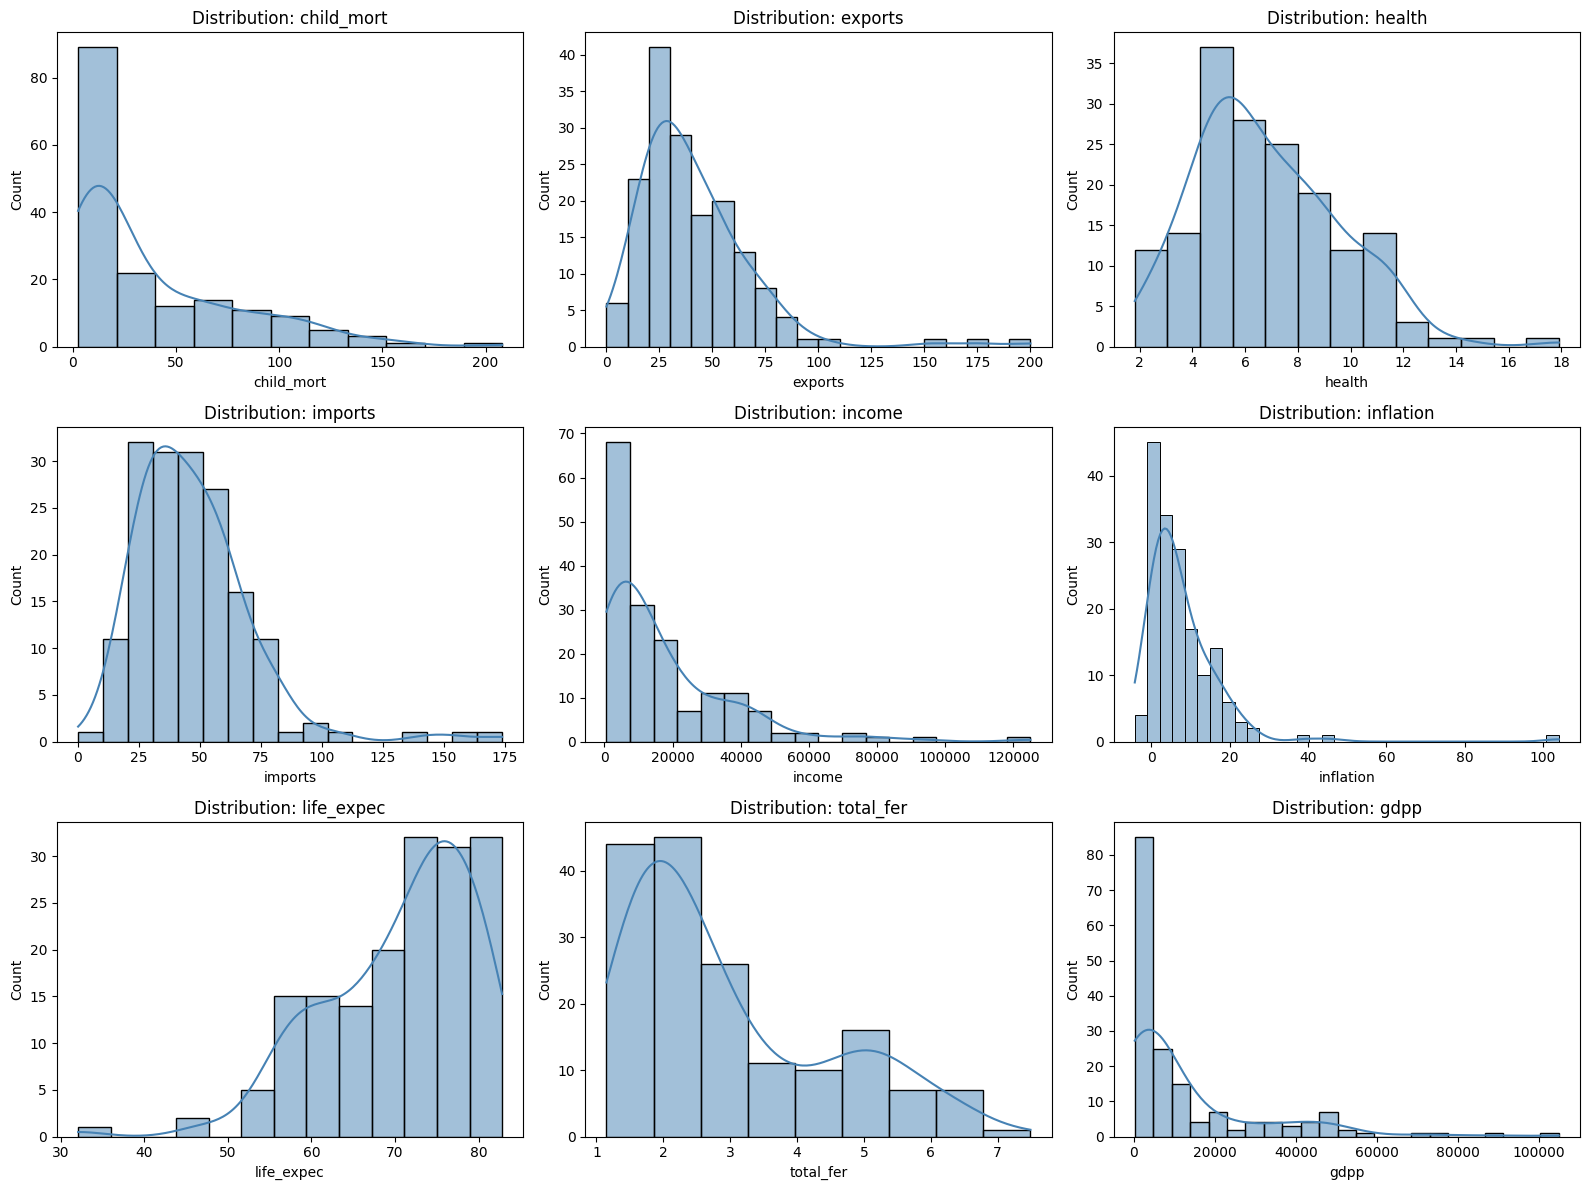

In [7]:
num_cols = [c for c in df.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=100)
plt.show()


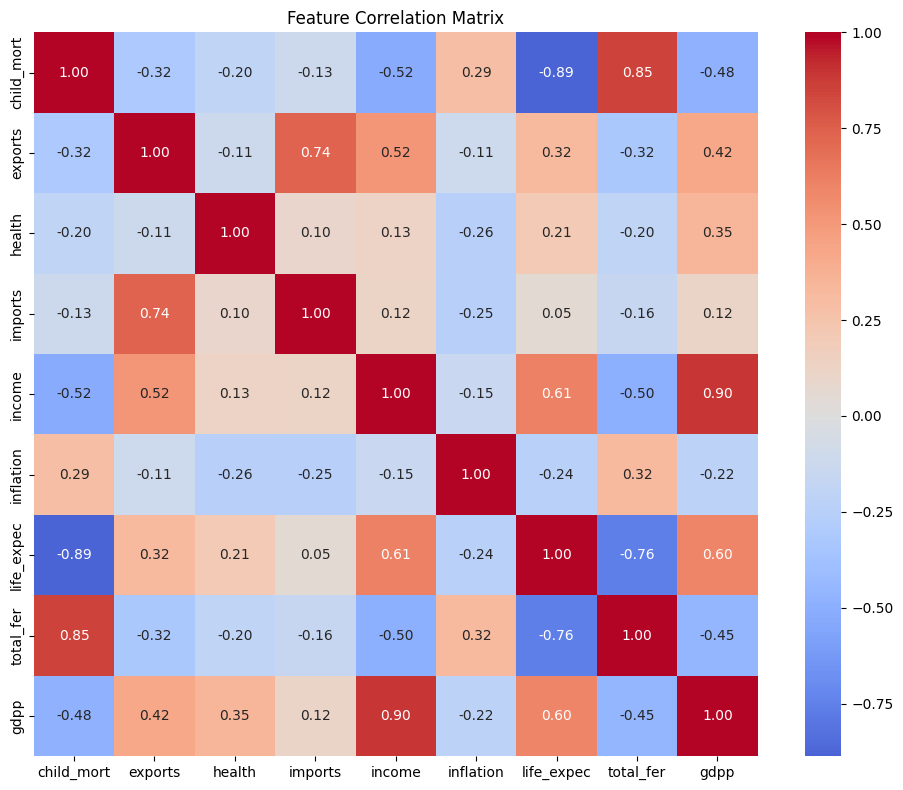

In [8]:
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('fig_correlation.png', dpi=100)
plt.show()


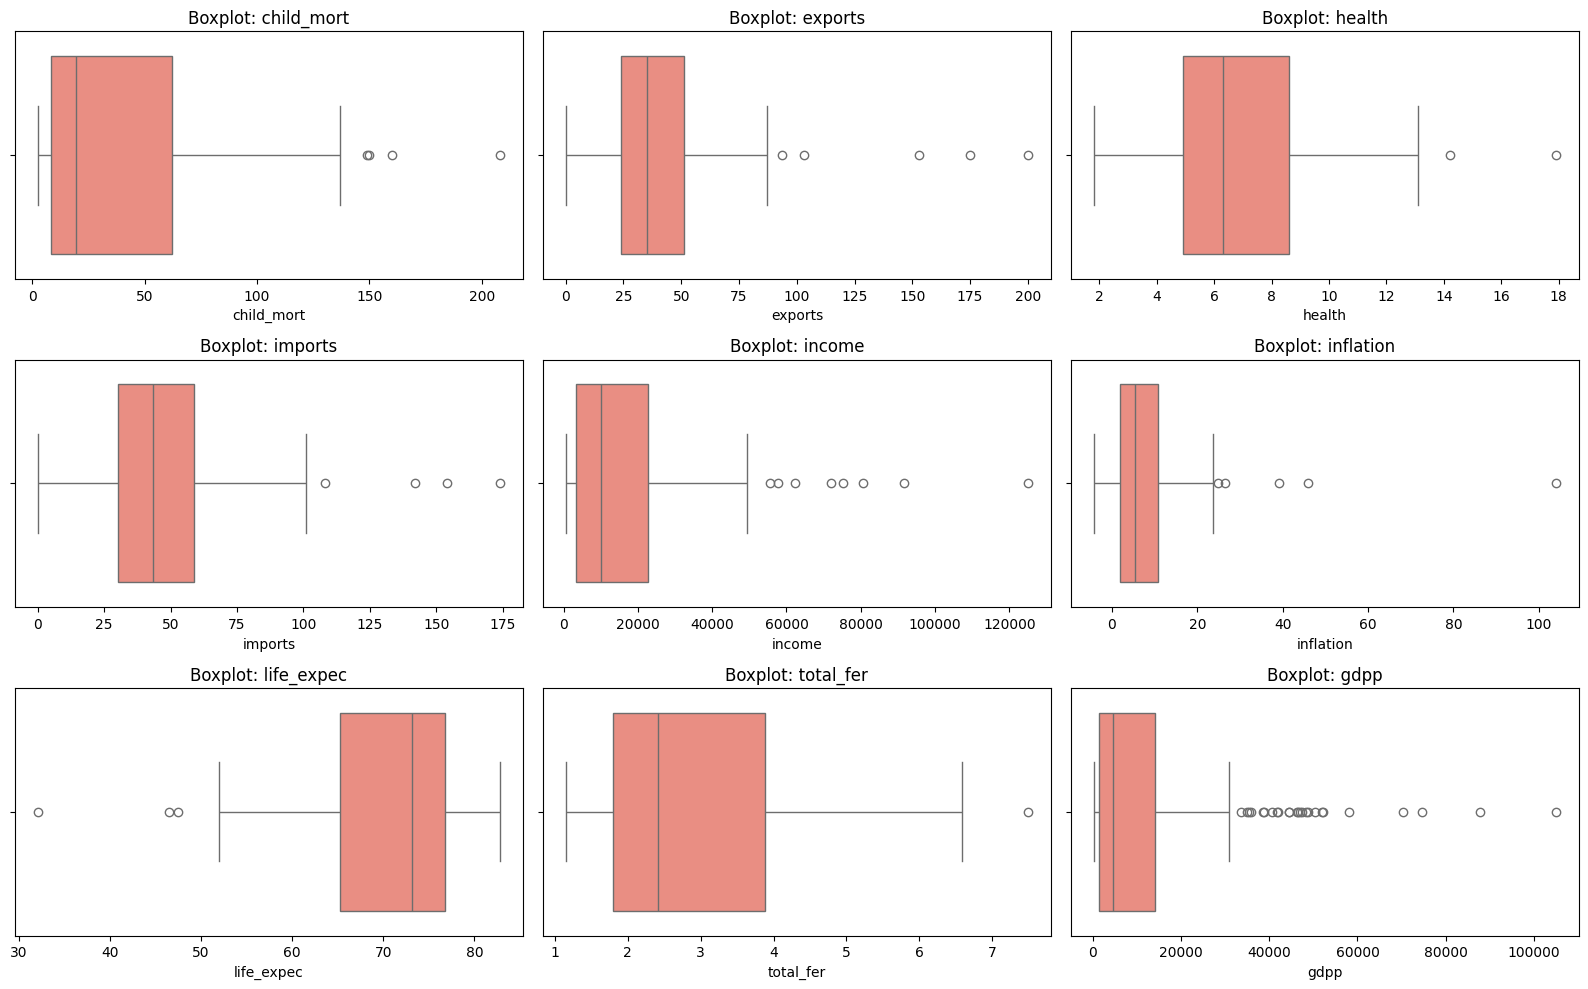

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x=df[col], ax=ax, color='salmon')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=100)
plt.show()


In [10]:
# Derived features
df_feat = df.copy()
df_feat['trade_balance'] = df_feat['exports'] - df_feat['imports']          # net trade position
df_feat['health_to_income'] = df_feat['health'] * df_feat['income'] / 100   # absolute health spend per capita

feature_cols = ['child_mort', 'exports', 'health', 'imports', 'income',
                 'inflation', 'life_expec', 'total_fer', 'gdpp',
                 'trade_balance', 'health_to_income']

X = df_feat[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_to_income
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,-1.541835,-0.723556
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,-0.784652,-0.380583
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376,0.676765,-0.453598
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268,1.333344,-0.693624
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817,-0.403413,-0.055177


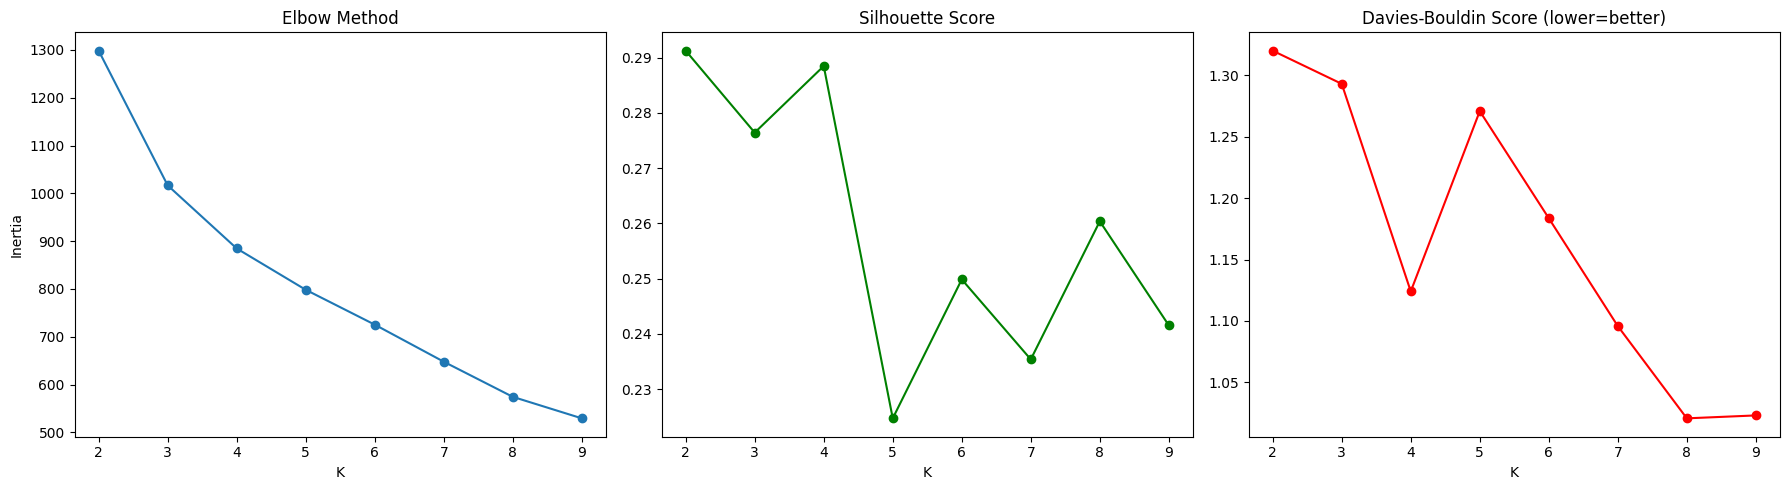

K=2: silhouette=0.291, davies_bouldin=1.320
K=3: silhouette=0.276, davies_bouldin=1.293
K=4: silhouette=0.288, davies_bouldin=1.124
K=5: silhouette=0.225, davies_bouldin=1.271
K=6: silhouette=0.250, davies_bouldin=1.184
K=7: silhouette=0.235, davies_bouldin=1.096
K=8: silhouette=0.260, davies_bouldin=1.021
K=9: silhouette=0.242, davies_bouldin=1.023


In [14]:
RANDOM_STATE = 42
inertias, silhouettes, db_scores = [], [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(list(K_range), inertias, marker='o'); axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(list(K_range), silhouettes, marker='o', color='green'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K')
axes[2].plot(list(K_range), db_scores, marker='o', color='red'); axes[2].set_title('Davies-Bouldin Score (lower=better)'); axes[2].set_xlabel('K')
plt.tight_layout()
plt.savefig('fig_kmeans_selection.png', dpi=100)
plt.show()

for k, s, d in zip(K_range, silhouettes, db_scores):
    print(f"K={k}: silhouette={s:.3f}, davies_bouldin={d:.3f}")


In [15]:
# K=3 gives a clean, interpretable, high-silhouette segmentation (Low / Medium / High development)
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_feat['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:\n", df_feat['kmeans_cluster'].value_counts().sort_index())
print("\nSilhouette score:", silhouette_score(X_scaled, df_feat['kmeans_cluster']))


Cluster sizes:
 kmeans_cluster
0    85
1    36
2    46
Name: count, dtype: int64

Silhouette score: 0.276436007032177


In [16]:
cluster_profile = df_feat.groupby('kmeans_cluster')[['child_mort', 'income', 'gdpp', 'life_expec', 'total_fer']].mean().round(1)
cluster_profile


,child_mort,income,gdpp,life_expec,total_fer
kmeans_cluster,,,,,
0,22.7,12704.0,6668.9,72.5,2.3
1,5.0,45672.2,42494.4,80.1,1.8
2,93.1,3024.4,1486.1,59.5,5.1


In [17]:
# Order clusters by mean gdpp to assign meaningful labels
order = cluster_profile.sort_values('gdpp').index.tolist()
label_map = {order[0]: 'Low Development', order[1]: 'Medium Development', order[2]: 'High Development'}
df_feat['segment'] = df_feat['kmeans_cluster'].map(label_map)

print(df_feat['segment'].value_counts())
df_feat[['country', 'child_mort', 'income', 'gdpp', 'segment']].sort_values('gdpp').head(10)


segment
Medium Development    85
Low Development       46
High Development      36
Name: count, dtype: int64


,country,child_mort,income,gdpp,segment
26,Burundi,93.6,764,231,Low Development
88,Liberia,89.3,700,327,Low Development
37,"Congo, Dem. Rep.",116.0,609,334,Low Development
112,Niger,123.0,814,348,Low Development
132,Sierra Leone,160.0,1220,399,Low Development
93,Madagascar,62.2,1390,413,Low Development
106,Mozambique,101.0,918,419,Low Development
31,Central African Republic,149.0,888,446,Low Development
94,Malawi,90.5,1030,459,Low Development
50,Eritrea,55.2,1420,482,Low Development


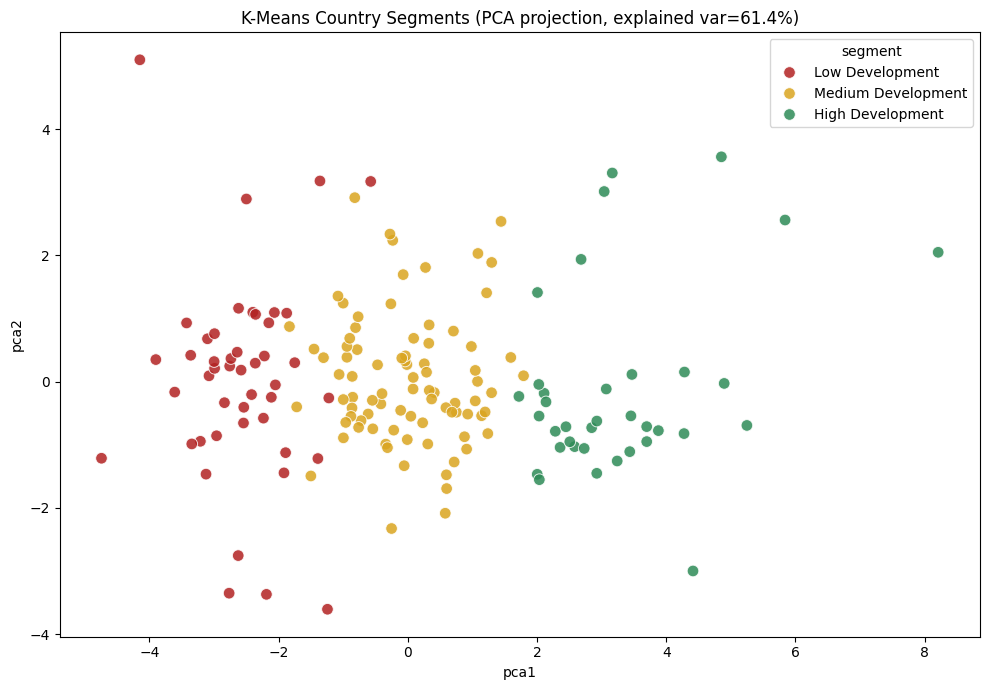

In [18]:
# Visualize segments via PCA (2D projection)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df_feat['pca1'], df_feat['pca2'] = X_pca[:, 0], X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_feat, x='pca1', y='pca2', hue='segment',
                 palette={'Low Development': 'firebrick', 'Medium Development': 'goldenrod', 'High Development': 'seagreen'},
                 s=70, alpha=0.85)
plt.title(f'K-Means Country Segments (PCA projection, explained var={pca.explained_variance_ratio_.sum():.1%})')
plt.tight_layout()
plt.savefig('fig_kmeans_pca.png', dpi=100)
plt.show()


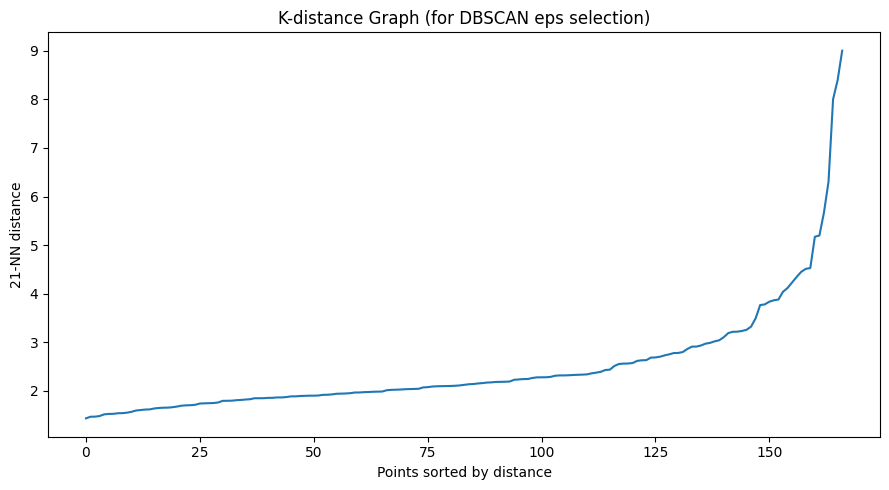

In [19]:
from sklearn.neighbors import NearestNeighbors

# Estimate eps via k-distance graph (k = 2*dim - 1, common heuristic)
k = 2 * X_scaled.shape[1] - 1
neighbors = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 5))
plt.plot(k_distances)
plt.title('K-distance Graph (for DBSCAN eps selection)')
plt.xlabel('Points sorted by distance'); plt.ylabel(f'{k}-NN distance')
plt.tight_layout()
plt.savefig('fig_dbscan_kdistance.png', dpi=100)
plt.show()


In [20]:
best_combo, best_score = None, -1
for eps in np.arange(1.0, 3.6, 0.2):
    for min_samples in [3, 4, 5, 6]:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2:
            continue
        mask = labels != -1
        if mask.sum() < 10:
            continue
        score = silhouette_score(X_scaled[mask], labels[mask])
        if score > best_score:
            best_score, best_combo = score, (eps, min_samples, n_clusters, (labels == -1).sum())

print(f"Best DBSCAN combo -> eps={best_combo[0]:.1f}, min_samples={best_combo[1]}, "
      f"clusters={best_combo[2]}, noise_points={best_combo[3]}, silhouette={best_score:.3f}")

dbscan = DBSCAN(eps=best_combo[0], min_samples=best_combo[1])
df_feat['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print(df_feat['dbscan_cluster'].value_counts().sort_index())


Best DBSCAN combo -> eps=1.0, min_samples=4, clusters=2, noise_points=115, silhouette=0.508
dbscan_cluster
-1    115
 0     37
 1     15
Name: count, dtype: int64


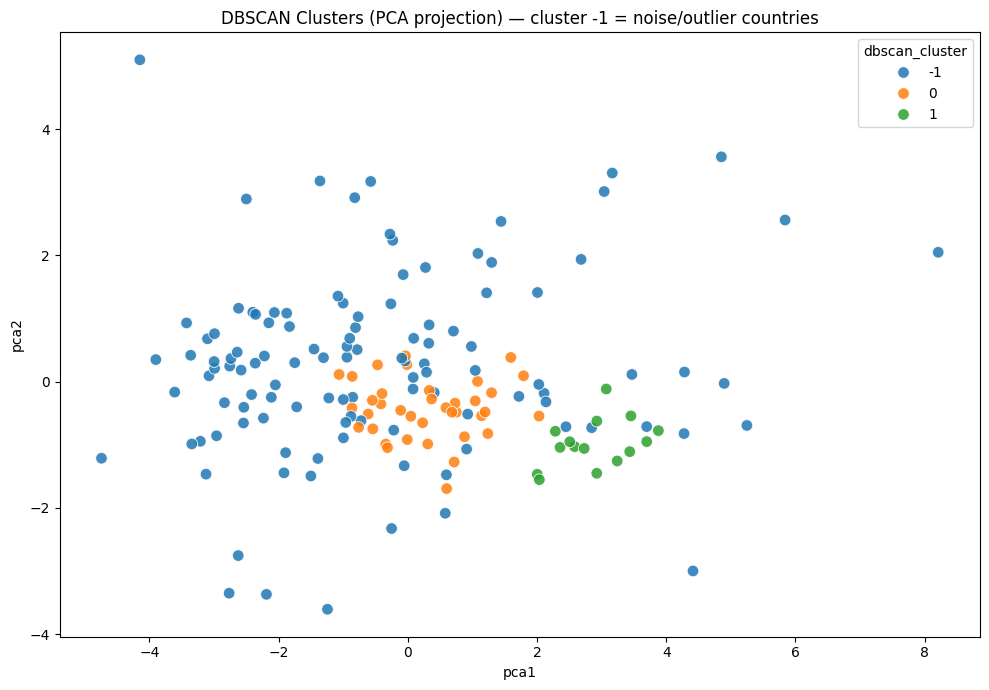


Countries flagged as noise/outliers by DBSCAN (extreme profiles):
['Afghanistan', 'Algeria', 'Angola', 'Argentina', 'Australia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brunei', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'China', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Cyprus', 'Czech Republic', 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Gabon', 'Gambia', 'Georgia', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kuwait', 'Kyrgyz Republic', 'Lao', 'Lesotho', 'Liberia', 'Libya', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives', 'Mali', 'Malta', 'Mauritania', 'Micronesia, Fed. Sts.', 'Moldova', 'Mongolia', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Netherlands', 'Niger', 'Nigeria', 'Norway', 'Oman', 'Pakis

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_feat, x='pca1', y='pca2', hue='dbscan_cluster', palette='tab10', s=70, alpha=0.85)
plt.title('DBSCAN Clusters (PCA projection) — cluster -1 = noise/outlier countries')
plt.tight_layout()
plt.savefig('fig_dbscan_pca.png', dpi=100)
plt.show()

print("\nCountries flagged as noise/outliers by DBSCAN (extreme profiles):")
print(df_feat.loc[df_feat['dbscan_cluster'] == -1, 'country'].tolist())


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_feat['segment'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

X_clf = df_feat[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler_clf = StandardScaler()
X_train_s = scaler_clf.fit_transform(X_train)
X_test_s = scaler_clf.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


{'High Development': 0, 'Low Development': 1, 'Medium Development': 2}
Train shape: (133, 11)  Test shape: (34, 11)


In [23]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 6, 8],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 2, 3],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1
)
rf_grid.fit(X_train_s, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best CV F1-macro:", rf_grid.best_score_)
best_rf = rf_grid.best_estimator_


Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 200}
Best CV F1-macro: 0.9636903256511099


In [24]:
y_pred_rf = best_rf.predict(X_test_s)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Test F1-macro:", f1_score(y_test, y_pred_rf, average='macro'))
print("\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))


Random Forest Test Accuracy: 1.0
Random Forest Test F1-macro: 1.0

                     precision    recall  f1-score   support

  High Development       1.00      1.00      1.00         7
   Low Development       1.00      1.00      1.00        10
Medium Development       1.00      1.00      1.00        17

          accuracy                           1.00        34
         macro avg       1.00      1.00      1.00        34
      weighted avg       1.00      1.00      1.00        34



In [25]:
xgb_param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'),
    xgb_param_dist, n_iter=40, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE
)
xgb_search.fit(X_train_s, y_train)

print("Best XGB params:", xgb_search.best_params_)
print("Best CV F1-macro:", xgb_search.best_score_)
best_xgb = xgb_search.best_estimator_


Best XGB params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV F1-macro: 0.9433873680722904


In [26]:
y_pred_xgb = best_xgb.predict(X_test_s)
print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Test F1-macro:", f1_score(y_test, y_pred_xgb, average='macro'))
print("\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))


XGBoost Test Accuracy: 0.9411764705882353
XGBoost Test F1-macro: 0.9259259259259259

                     precision    recall  f1-score   support

  High Development       1.00      0.71      0.83         7
   Low Development       1.00      1.00      1.00        10
Medium Development       0.89      1.00      0.94        17

          accuracy                           0.94        34
         macro avg       0.96      0.90      0.93        34
      weighted avg       0.95      0.94      0.94        34



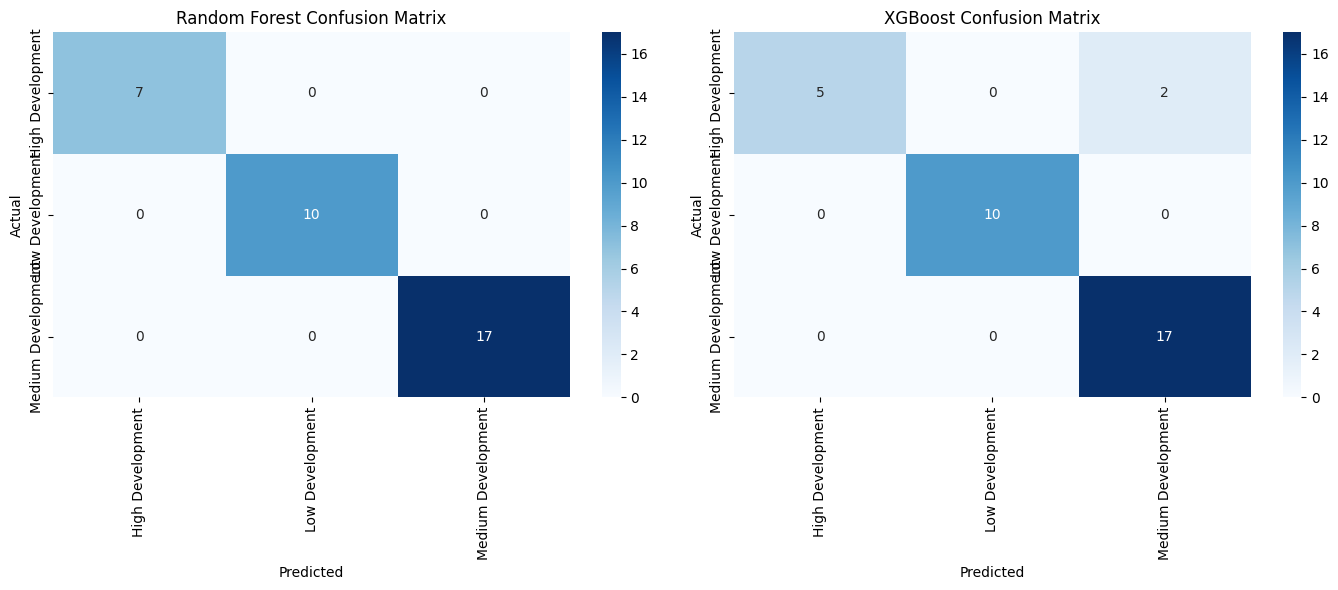

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (name, y_pred) in zip(axes, [('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('fig_confusion_matrices.png', dpi=100)
plt.show()


In [28]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Test Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    'Test F1-macro': [f1_score(y_test, y_pred_rf, average='macro'), f1_score(y_test, y_pred_xgb, average='macro')],
    'Best CV F1-macro': [rf_grid.best_score_, xgb_search.best_score_]
}).round(4)
results


,Model,Test Accuracy,Test F1-macro,Best CV F1-macro
0,Random Forest,1.0000,1.0000,0.9637
1,XGBoost,0.9412,0.9259,0.9434


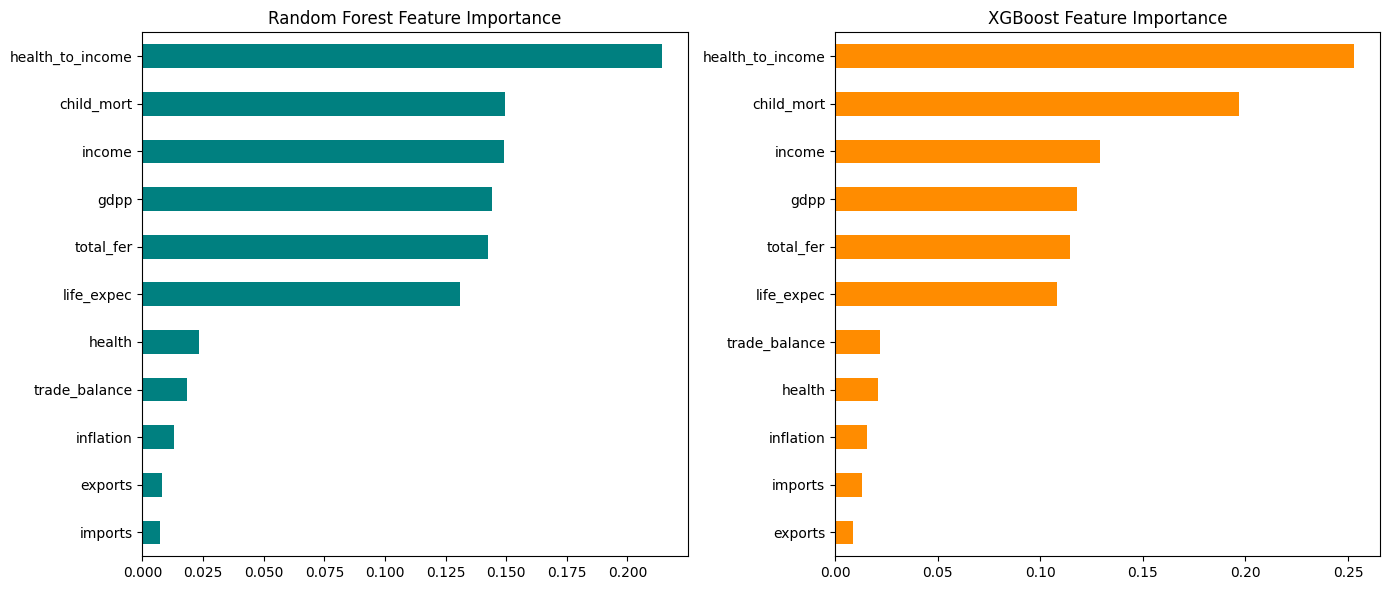

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

rf_importance = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
rf_importance.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Random Forest Feature Importance')

xgb_importance = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=True)
xgb_importance.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.savefig('fig_feature_importance.png', dpi=100)
plt.show()
